# Welcome to Australian CPI Forecasting

[![content: AI-generated](_static/badges/ai-generated.svg)](ai-acknowledgement) [![content: human-reviewed & edited](_static/badges/human-reviewed-edited.svg)](ai-acknowledgement)

(ai-acknowledgement)=
```{admonition} AI acknowledgement
:class: caution
I want to be upfront about how this book was made: **a large part of it was written with AI.**

**Why I used AI.** This project sits outside my own field. Forecasting inflation draws on
macroeconomics and monetary policy (what CPI and trimmed-mean inflation measure, how the RBA
sets the cash rate), time-series econometrics (structural VARs, cointegration and
unit-root tests, impulse responses) and credit-risk modelling (default probabilities and
expected credit losses). I'm not trained in any of these, so I leaned on AI to learn them as I
went and to write the parts that depend on that knowledge, especially the formulas and their
step-by-step explanations.

I then checked the results myself to see whether they hold up. What I can't promise is that the
work matches what a specialist would produce, or published research. My time was limited, and I
couldn't check every formula, assumption and result to an expert's standard. Please read the
methods and numbers as a careful student's attempt, not as professional advice.
[How much to trust each part](how-much-to-trust), further down this page, says where I know
things are shaky. The [documented limitations](appendix_eda/15_documented_limitations) list
the technical follow-ups from the data analysis.

**How AI was used.** I used two AI tools, **Codex** (OpenAI) and **Claude Code** (Anthropic), and
they worked together rather than one after the other. The routine was a simple review loop built
on shared notes:

**Codex implements and tests → Claude reviews the diff → Codex applies the fixes → I review, re-run and edit**

- **Shared context.** Both tools read the same short set of project notes before starting (a
  project brief, a code map, status rules and a writing-style guide, all in the `.ai/` folder), so
  they were working from the same facts.
- **A second pair of eyes.** Codex mostly wrote and tested the code. Claude mostly reviewed its
  changes and worked on the documentation and wording. Either tool could pick up the other's job
  when needed, and they never edited the same file at the same time.
- **Claims kept honest.** The status rules keep a clear line between what's implemented,
  scaffolded, planned and deployed, so the text doesn't oversell the work.
- **Tests as a safety net.** Code changes were checked by running the project's automated tests,
  not just by reading them. Passing tests show the code does what it was written to do. They don't
  show that the formulas or the economics are right, which is why my own review still matters.

**What the tags mean.** Every page of this book, and the project README, opens with two tags side
by side. They describe the page as a whole, not each paragraph, and they're meant to be read
together: AI wrote the first draft, then I went through it.

![content: AI-generated](_static/badges/ai-generated.svg)

The first draft of the page (text, code and charts) was written by Codex and/or Claude from my
prompts and the shared project notes, usually with the other model checking it. Mistakes are most
likely in the formulas, claims and interpretation that need specialist knowledge.

![content: human-reviewed & edited](_static/badges/human-reviewed-edited.svg)

Then I went through the page myself:

- I read the outputs (numbers, tables, charts) and checked they say what the text claims.
- I re-ran the code to see whether the results came out the same.
- I edited the wording for clarity and tone, and to remove anything that overclaims.
- I fixed inconsistencies, both between pages and between the text and the numbers.

This is a review by a non-specialist, not an expert sign-off, and it covers the page as I last
read it. If AI edits a page after that, I'll drop its human-reviewed tag until I've looked again.

The markdown notes in the project's `reports/` folder carry the AI-generated tag only. AI
drafted them, and I haven't marked them as human-reviewed. The CSV files beside them are results
the project's code computes from the data, so they aren't AI-written text and aren't tagged.
```

```{tip}
**Try it live, no install:** <https://cpi-forecast-demo.streamlit.app/>. Run a live forecast, watch the Ensemble's
simulated paths, try your own shock in the Scenario Engine and see the RBA call.
```

(how-much-to-trust)=
## How much to trust each part

The human-reviewed tag means I read and re-ran the work, not that a specialist signed it off.
Here's what backs each part, most checkable first. See [Key Findings](00_results_at_a_glance) and
[§5 Evaluation](05_evaluation) for the detail.

**Checkable by anyone**

| Part | Covers | What backs it up | Keep in mind |
|---|---|---|---|
| Code and pipeline | Data download and cleaning, features, model code. | 218 tests passed on 24 September 2026. Two book rebuilds gave identical pages, and retraining on newer packages gave 43 of 44 identical files (the other differs by a date). **Run it yourself:** `python -m pytest tests` prints your own pass count and runtime at the end (current checkout: `218 passed`; about 3 minutes). The same recipe shows how to restore the saved models in seconds ([README: Reproduce the results](https://github.com/JuanVu1810/Australian-CPI-Forecast#reproduce-the-results)). | Tests check the code, not the modelling. Simulated results can shift slightly on other hardware. An older classifier report differs in 4 of 82 calls, and I haven't found why. [Chapter 6](06_deployment) lists what wasn't rerun. |
| Live API | The FastAPI service on Google Cloud Run ([Chapter 6](06_deployment)). The Streamlit demo is hosted separately and isn't covered here. | Redeployed and verified on 21 September 2026. Point forecasts, intervals and the credit stress test matched a local run to within 1e-6. **Try it yourself:** request a forecast from the [API docs](https://cpi-forecast-api-887232555982.asia-southeast1.run.app/docs). The Ensemble's four headline forecasts should read 3.154, 3.128, 2.938 and 3.037. | The two simulated endpoints differ slightly (scenario forecast by up to 0.03 percentage points, RBA action probabilities by up to 0.2). A snapshot: new pushes don't redeploy it. |

**Measured on unseen data, with limits**

| Part | Covers | What backs it up | Keep in mind |
|---|---|---|---|
| Inflation accuracy | SARIMA, Elastic Net and the Ensemble, for headline and trimmed-mean CPI ([§4.1](04_modeling/41_sarima) to [§4.3](04_modeling/43_ensemble)). | Ensemble errors about 24% smaller than a naive benchmark for headline CPI, 21% for trimmed mean. | Tested on revised data, which flatters the models a little. Its edge over SARIMA is small. Against the RBA (1.64 vs 1.69 points, 424 forecasts) it's too close to call. |
| Forecast ranges | The 80% ranges around those forecasts ([§5](05_evaluation)). | The 80% ranges were checked against what happened. | Too narrow. They caught the result about 78% of the time for SARIMA and about two-thirds for Elastic Net and the Ensemble, and did worse in 2020 to 2023. |
| RBA next-move classifier | Predicting the next RBA cut, hold or hike ([§4.6](04_modeling/46_rba_classifier)). | Scored on past RBA decisions. | A simple rule (forecast above or below the 2 to 3% target band) did best, but its lead isn't statistically clear. The "hike" call rests on a 3.15% forecast just over the 3% line. Five models say hold and one says cut. |

**Judgment calls and illustrative only**

| Part | Covers | What backs it up | Keep in mind |
|---|---|---|---|
| "What if" scenarios (SVAR) | Which factors drive inflation, and the Scenario Engine ([§4.4](04_modeling/44_svar), [§4.5](04_modeling/45_scenario_engine)). | The direction makes sense: higher unemployment lowers inflation, and higher commodity prices or inflation expectations raise it. | The cash-rate response shows the price puzzle, and the models still fail their own diagnostics. |
| Credit stress test | Expected credit losses on mortgages and personal loans if unemployment rises ([§4.7](04_modeling/47_credit_stress)). | Built from NAB's published loan and default figures and an RBA research paper. | Deliberately larger than a real provision, and not checked against anything NAB hasn't disclosed. Don't compare it with NAB's actual figures. |

If you're a specialist, the SVAR set-up and the credit-stress assumptions are where I'd most want
your review.

> 👋 **If the notes above haven't made you click away, welcome to this project, and thanks for reading!** 😊
> **If you have questions, feedback, or spot something a specialist would catch, I'd love to hear**
> **from you: [vducviethoang@gmail.com](mailto:vducviethoang@gmail.com) or**
> **[LinkedIn](https://www.linkedin.com/in/duc-viet-hoang-vu).**

## Why this exists

Most university coursework ends the same way: a notebook cleans some data, fits a
model, prints a forecast, gets a mark, and is never opened again. Mine was no
exception. [The original assignment](https://github.com/JuanVu1810/Australian-CPI-Forecast/blob/main/notebooks/cpi_forecast_V1.ipynb)
was a single notebook that cleaned ABS CPI data (which was handed over, not extracted) and fit a quarterly SARIMA
model. It did exactly what it was asked to do, and then it was done.

This Jupyter book is that notebook’s afterlife. The original question is still here (use the historical CPI data alone to forecast the next 8 quarters), while everything downstream of it is new: reproducible data retrieval and ETL, a DuckDB analytics layer, SARIMA/Elastic Net/Ensemble competing on genuine walk-forward evidence, a structural VAR for attributing why CPI moved when it did, a scenario engine, an RBA policy-action classifier, an illustrative credit-stress test, and a FastAPI + Streamlit app to serve all of it (with a live Cloud Run deployment behind it too).

## The question, stated with appropriate gravity

Officially, and for the record:

**Can external macroeconomic features, including unemployment, cash rate,
producer prices, commodity/oil prices, and business inflation expectations
improve Australian CPI forecasts with comparison to a seasonal-naive baseline and
the RBA's own published forecasts, for both headline (`cpi_yoy`) and
trimmed-mean (`trimmed_mean_cpi_yoy`) inflation?**

It's the sentence every chapter after this one exists to answer.

## How this book is organised

This book follows the CRISP-DM structure used throughout the project:
Business Understanding, Data Understanding, Data Preparation, Modeling,
Evaluation, Deployment, and Conclusion. Every equation is taken from the
code that actually runs and followed by a plain-English, step-by-step
explanation. No background in time series or classification is assumed (hopefully).

**Two ways to read it.** If you want the results in plain English, start with [Key Findings](00_results_at_a_glance). If you want to know how they were made, follow the chapters in order, or use the "Full method" links on the Key Findings page to jump straight to the chapter behind a result.

In [9]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

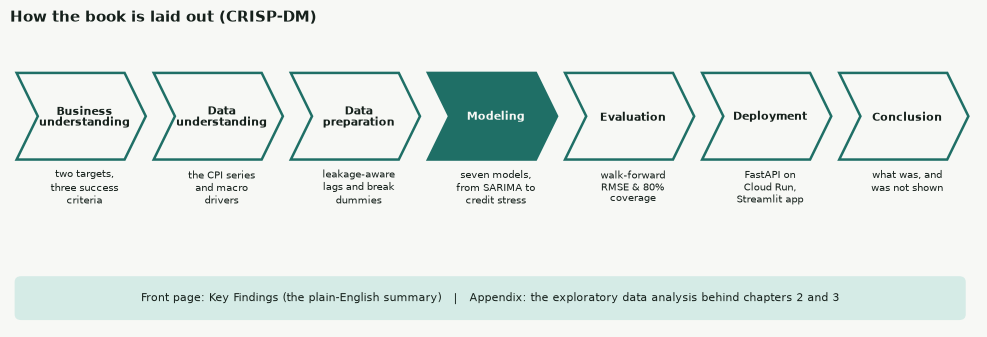

In [11]:
import textwrap
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

stages = [
    ("1", "Business\nunderstanding", "two targets, three success criteria"),
    ("2", "Data\nunderstanding", "the CPI series and macro drivers"),
    ("3", "Data\npreparation", "leakage-aware lags and break dummies"),
    ("4", "Modeling", "seven models, from SARIMA to credit stress"),
    ("5", "Evaluation", "walk-forward RMSE & 80% coverage"),
    ("6", "Deployment", "FastAPI on Cloud Run, Streamlit app"),
    ("7", "Conclusion", "what was, and was not shown"),
]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_xlim(0, 14.6)
ax.set_ylim(-0.8, 4.2)
ax.axis("off")

w, gap, top = 1.95, 0.12, 3.6

for i, (num, name, blurb) in enumerate(stages):
    x = 0.1 + i * (w + gap)
    tip = 0.32
    face = ACCENT if num == "4" else PAPER
    edge = ACCENT
    
    # Draw Chevron Polygon
    ax.add_patch(Polygon([
        (x, top), 
        (x + w - tip, top), 
        (x + w, top - 0.75), 
        (x + w - tip, top - 1.5), 
        (x, top - 1.5),
        (x + tip, top - 0.75)
    ], closed=True, facecolor=face, edgecolor=edge, linewidth=1.8))
    
    # Header Text inside the chevron shape
    ax.text(
        x + w / 2 + 0.05, top - 0.75, name, 
        ha="center", va="center", fontsize=8, fontweight="bold",
        color=PAPER if num == "4" else INK, linespacing=1.05
    )
    
    # Wrapped blurb below the chevron shape
    ax.text(
        x + w / 2 + 0.05, top - 1.65, "\n".join(textwrap.wrap(blurb, 15)), 
        ha="center", va="top", fontsize=7.5, linespacing=1.2, color=INK
    )

# Bottom Banner Box (Adjusted dimensions & padding)
ax.add_patch(FancyBboxPatch(
    (0.1, -0.65), 14.3, 0.7, 
    boxstyle="round,pad=0.03,rounding_size=0.1", 
    facecolor=ACCENT_SOFT, edgecolor="none", alpha=0.6
))

ax.text(
    7.25, -0.30, 
    "Front page: Key Findings (the plain-English summary)   |   Appendix: the exploratory data analysis behind chapters 2 and 3",
    ha="center", va="center", fontsize=8, color=INK
)

ax.set_title("How the book is laid out (CRISP-DM)", loc="left", fontsize=11, fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

```{admonition} Static book vs. the live app
:class: note
This book is a static, pinned snapshot, good for reading end to end. A handful
of sections (the Ensemble's Monte-Carlo reveal, the Scenario Engine, and the RBA
Policy Classifier's live refresh) are genuinely interactive and can't be replayed
on a static page; those sections show a fixed example plus a callout box telling
you how to reach the live version instead.

- **Live, interactive app:** <https://cpi-forecast-demo.streamlit.app/> (or run
  `streamlit run app/streamlit_app.py` from the project root).
- **Live forecast/scenario API:** <https://cpi-forecast-api-887232555982.asia-southeast1.run.app/docs>
  (verified live 2026-09-21; serves `/forecast/all`, `/forecast/trimmed-mean/all`,
  `/forecast/scenario`, `/rba-action` and `/credit-risk/stress-test` from baked local
  MLflow runs; a redeploy step is not wired into CI, so it may lag the repository).
- **Source code:** <https://github.com/JuanVu1810/Australian-CPI-Forecast>
```